In [ ]:
!pip install "transformers==4.36.0" --q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.8/126.8 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 85.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 119.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.6.0 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.36.0 which is incompatible.
gradio 6.19.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import torch
from datasets import load_dataset
import transformers
from transformers import AutoTokenizer, AutoModelForMaskedLM

## Example: Extracting embeddings from a pretrained model
Huggingface page: https://huggingface.co/InstaDeepAI/nucleotide-transformer-v2-100m-multi-species

###1. Load the pretrained model using the `from_pretrained` function from the `AutoModelForMaskedLM` interface.

In [ ]:
MODEL_NAME = "InstaDeepAI/nucleotide-transformer-v2-100m-multi-species"

In [ ]:
# Load the model
model = AutoModelForMaskedLM.from_pretrained("InstaDeepAI/nucleotide-transformer-v2-100m-multi-species", trust_remote_code=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

esm_config.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/InstaDeepAI/nucleotide-transformer-v2-100m-multi-species:
- esm_config.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


modeling_esm.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/InstaDeepAI/nucleotide-transformer-v2-100m-multi-species:
- modeling_esm.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when 

model.safetensors:   0%|          | 0.00/392M [00:00<?, ?B/s]

### 2. Create and tokenise a dummy DNA sequence

In [ ]:
tokeniser = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)

In [ ]:
sequence = "ACGTAGCATCGGATCTATCTATCGACACTTGGTTATCGATCTACGAGCATCTCGTTAGC"

In [ ]:
tokenised = tokeniser(sequence,
                      return_tensors="pt",
                      padding="max_length",
                      max_length=512
                      )
token_ids = tokenised["input_ids"] # Get the input_ids, which are our token ids
print(token_ids.shape)

torch.Size([1, 512])


In [ ]:
# Let's look at the tokens
tokeniser.decode(token_ids[0])

'<cls> ACGTAG CATCGG ATCTAT CTATCG ACACTT GGTTAT CGATCT ACGAGC ATCTCG T T A G C <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <p

### 3. Compute the embeddings

The hidden states are the internal representations of the input sequence at different layers of the model. They capture contextual information about the DNA sequence, which can be used for downstream tasks.

In [60]:
outputs = model(token_ids)
print(outputs)

MaskedLMOutput(loss=None, logits=tensor([[[ -8.9657,  -9.0506,  -8.9147,  ...,   3.4873,   5.2902,   7.1310],
         [-10.5617, -10.6926, -10.6061,  ...,  -1.9070,  -1.7204,   3.2472],
         [-12.3263, -12.1794, -12.4663,  ...,  -5.1065,  -3.2634,  -0.0945],
         ...,
         [  1.7660,   1.7017,   1.9731,  ...,  -2.9326,   7.4498,  -0.3118],
         [  1.8405,   1.7970,   2.0332,  ...,  -2.7471,   7.5498,  -0.1602],
         [  2.4748,   2.4571,   2.6810,  ...,  -2.3395,   7.6609,   0.2616]]],
       grad_fn=<AddBackward0>), hidden_states=None, attentions=None)


In [61]:
hidden_states = outputs[0]
print(hidden_states.shape)

torch.Size([1, 512, 4107])


1: Number of sequences

512: Length of sequences

4107: Size of vocabulary, i.e., number of possible tokens

###4. Manipulate the embeddings

We want to calculate the mean of the hidden states across a specific dimension, here, the last layer. At this stage, the hidden state represents a culmination of all the model's computations, and provides the most informative context.

`dim=0`: The mean is calculated across the sequence length dimension. The hidden states are averaged for each token position in the sequence, resulting in a single vector representing the entire sequence.

In [62]:
embedding_mean = torch.mean(hidden_states[-1], dim=0)
print(embedding_mean.shape)

torch.Size([4107])


4107: Size of vocabulary, i.e., number of possible tokens

**Try it yourself: Apply max pooling instead of mean pooling to the embeddings.**

In [ ]:
embedding_max = # Your code here

#### Solution

In [ ]:
embedding_max = torch.max(hidden_states[0], dim=0)[0]

###5. Visualise embeddings

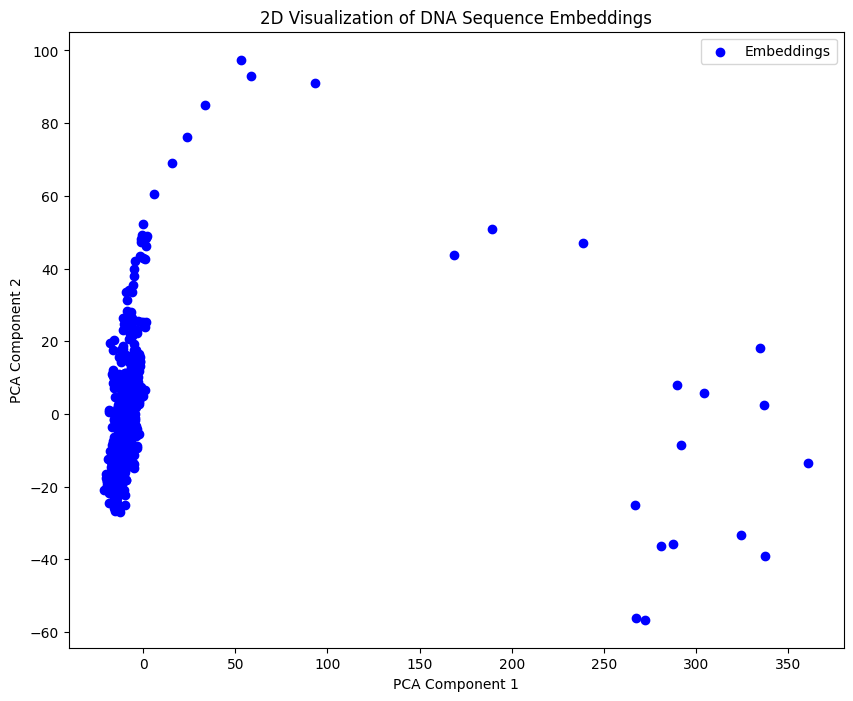

In [64]:
# Performing PCA for dimensionality reduction
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(hidden_states[-1].detach().numpy())

# Plotting the results
plt.figure(figsize=(10, 8))
plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], color='b', label="Embeddings")

plt.title('2D Visualization of DNA Sequence Embeddings')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.show()